## Classification Random Forest

- author : Sylvie Dagoret-Campagne
- affiliation : IJCLab/IN2P3/CNRS
- creation date : 2025-11-06 (at NERSC **kernel desc-td-env-dev**)
- last update : 2025-11-10 laptop on (**kernel pytorch-cpu-py312**)

✅ Ce notebook fait tout :

- Parcourt plusieurs types de SN et transients.
- Lit HEAD + PHOT .FITS.gz compressés.
- Filtre les bandes bidon '-'.
- Extrait des features simples (flux max, MJD du pic, NOBS, redshift).
- Visualise une courbe multibande d’exemple.

In [1]:
# ===============================================
# Notebook Mini-ELAsTiCC2 : Lecture + Features + ML
# ===============================================

# 1️⃣ Import des librairies
import os,socket
import fitsio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
def is_on_nersc():
    # Vérifier le nom d'hôte
    hostname = socket.gethostname()
    nersc_hostnames = ["perlmutter", "cori", "nersc.gov"]
    host_check = any(nersc_host in hostname for nersc_host in nersc_hostnames)

    # Vérifier les variables d'environnement
    nersc_vars = ["NERSC_HOST", "SLURM_JOB_ID", "CRAY_SYSTEM_NAME"]
    env_check = any(var in os.environ for var in nersc_vars)

    return host_check or env_check

if is_on_nersc():
    print("Je suis sur un système NERSC.")
else:
    print("Je suis sur mon laptop ou un autre système.")


Je suis sur mon laptop ou un autre système.


In [3]:
# -----------------------------
# 2️⃣ Définir les chemins NERSC
# -----------------------------

In [4]:
# 2️⃣ Définir le chemin des données et types à analyser
if is_on_nersc():
    print("Configuration pour NERSC : utilisation des GPU ou des chemins spécifiques.")
    # Exemple : charger des données depuis un chemin NERSC
    BASE_PATH = "/global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"

else:
    print("Configuration pour laptop : utilisation des ressources locales.")
    # Exemple : charger des données depuis un chemin local
    BASE_PATH = "/Users/dagoret/DATA/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"

Configuration pour laptop : utilisation des ressources locales.


Shape features : (120, 14)
Exemple features :
     flux_max_Y  mjd_peak_Y    flux_max_r  mjd_peak_r    flux_max_g  \
0  4752.936523  60967.0332  10832.589844  60938.0399  12285.958008   
1  8060.200195  60599.2872  13974.723633  60612.3360   5653.575195   
2  9413.978516  60395.2067  32289.046875  60377.1782  29886.800781   
3  3581.779053  60540.3078   5547.472656  60527.3094   5258.897461   
4  5266.664551  60919.3044  12668.076172  61121.3049  14648.594727   

   mjd_peak_g    flux_max_i  mjd_peak_i    flux_max_u  mjd_peak_u  \
0  60938.0151   5940.501465  60945.0880   7888.285645  60937.1071   
1  61085.2029  12887.894531  60601.3290   3543.085449  61085.1795   
2  60372.1454  15945.262695  60370.1779  24977.529297  60375.1156   
3  60291.0970   4008.102295  60523.4269   3609.559082  60287.1708   
4  61121.2809   8097.628418  60911.3270  11464.478516  61118.2449   

     flux_max_z  mjd_peak_z  NOBS  REDSHIFT_FINAL  
0   4751.000488  60948.0698    33        0.438268  
1  10553.8310

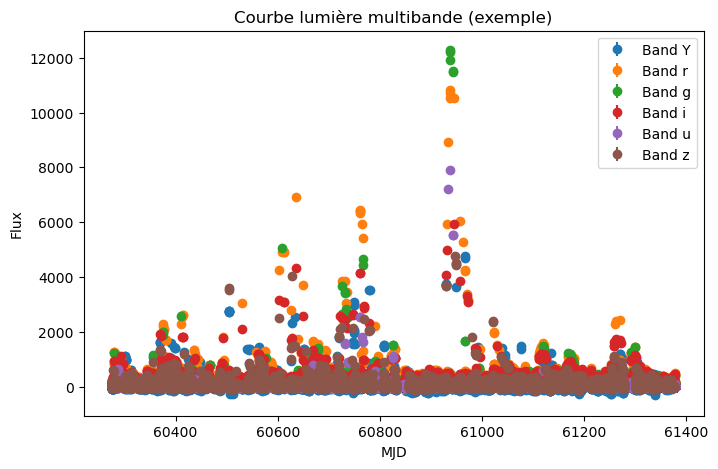

Classification report :

                                   precision    recall  f1-score   support

    ELASTICC2_TRAIN_02_SNIa-SALT3       1.00      0.92      0.96        12
ELASTICC2_TRAIN_02_SNIb-Templates       0.67      0.67      0.67        12
ELASTICC2_TRAIN_02_SNIc-Templates       0.69      0.75      0.72        12

                         accuracy                           0.78        36
                        macro avg       0.79      0.78      0.78        36
                     weighted avg       0.79      0.78      0.78        36

Confusion matrix :

[[11  1  0]
 [ 0  8  4]
 [ 0  3  9]]


In [5]:
sample_types = [
    "ELASTICC2_TRAIN_02_SNIa-SALT3",
    "ELASTICC2_TRAIN_02_SNIc-Templates",
    "ELASTICC2_TRAIN_02_SNIb-Templates"
]

# 3️⃣ Extraction de features
features_list = []
labels = []

for sn_type in sample_types:
    type_dir = os.path.join(BASE_PATH, sn_type)
    
    # Lister HEAD et PHOT
    head_files = sorted([f for f in os.listdir(type_dir) if "HEAD" in f])
    phot_files = sorted([f for f in os.listdir(type_dir) if "PHOT" in f])
    
    for head_file, phot_file in zip(head_files, phot_files):
        head_data = fitsio.FITS(os.path.join(type_dir, head_file))[1].read()
        phot_data = fitsio.FITS(os.path.join(type_dir, phot_file))[1].read()
        
        # Filtrer les bandes bidon et enlever espaces
        bands = set(b.strip() for b in phot_data["BAND"] if b.strip() != '-')
        
        feature_dict = {}
        for b in bands:
            mask = np.array([x.strip() for x in phot_data["BAND"]]) == b
            if np.sum(mask) > 0:
                feature_dict[f"flux_max_{b}"] = np.max(phot_data["FLUXCAL"][mask])
                feature_dict[f"mjd_peak_{b}"] = phot_data["MJD"][mask][np.argmax(phot_data["FLUXCAL"][mask])]
            else:
                feature_dict[f"flux_max_{b}"] = 0
                feature_dict[f"mjd_peak_{b}"] = 0
        
        # Features globales depuis HEAD
        feature_dict["NOBS"] = head_data["NOBS"][0]
        feature_dict["REDSHIFT_FINAL"] = head_data["REDSHIFT_FINAL"][0]
        
        features_list.append(feature_dict)
        labels.append(sn_type)

# Convertir en DataFrame
X = pd.DataFrame(features_list)
y = np.array(labels)

print("Shape features :", X.shape)
print("Exemple features :\n", X.head())

# 4️⃣ Visualiser un objet (optionnel)
head_file = os.path.join(BASE_PATH, sample_types[0], sorted([f for f in os.listdir(os.path.join(BASE_PATH, sample_types[0])) if "HEAD" in f])[0])
phot_file = head_file.replace("HEAD", "PHOT")
phot_data = fitsio.FITS(phot_file)[1].read()

bands = set(b.strip() for b in phot_data["BAND"] if b.strip() != '-')
plt.figure(figsize=(8,5))
for b in bands:
    mask = np.array([x.strip() for x in phot_data["BAND"]]) == b
    plt.errorbar(phot_data["MJD"][mask], phot_data["FLUXCAL"][mask],
                 yerr=phot_data["FLUXCALERR"][mask], fmt='o', label=f'Band {b}')
plt.xlabel("MJD")
plt.ylabel("Flux")
plt.title("Courbe lumière multibande (exemple)")
plt.legend()
plt.show()

# 5️⃣ Split train/test et entraînement RandomForest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 6️⃣ Prédiction et évaluation
y_pred = clf.predict(X_test)
print("Classification report :\n")
print(classification_report(y_test, y_pred))
print("Confusion matrix :\n")
print(confusion_matrix(y_test, y_pred))


🔹 Features enrichies + ML : Ce que cette version apporte

- Plus de features par bande → plus de signal pour ML
rise_time donne une idée de la montée de la lumière (utile pour différencier types de SN)
- Toujours prêt à exécuter sur NERSC avec ELAsTiCC2 Training Sample 2
- Compatible avec RandomForest, facilement échangeable avec d’autres modèles (XGBoost, PyTorch, …)

In [6]:
# ===============================================
# Notebook Mini-ELAsTiCC2 v2 : Features enrichies + ML
# ===============================================

import os
import fitsio
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix



features_list = []
labels = []

for sn_type in sample_types:
    type_dir = os.path.join(BASE_PATH, sn_type)
    head_files = sorted([f for f in os.listdir(type_dir) if "HEAD" in f])
    phot_files = sorted([f for f in os.listdir(type_dir) if "PHOT" in f])
    
    for head_file, phot_file in zip(head_files, phot_files):
        head_data = fitsio.FITS(os.path.join(type_dir, head_file))[1].read()
        phot_data = fitsio.FITS(os.path.join(type_dir, phot_file))[1].read()
        
        bands = set(b.strip() for b in phot_data["BAND"] if b.strip() != '-')
        feature_dict = {}
        
        for b in bands:
            mask = np.array([x.strip() for x in phot_data["BAND"]]) == b
            flux = phot_data["FLUXCAL"][mask]
            mjd = phot_data["MJD"][mask]
            
            if len(flux) > 0:
                flux_max = np.max(flux)
                flux_min = np.min(flux)
                flux_mean = np.mean(flux)
                flux_std = np.std(flux)
                
                # MJD du pic
                mjd_peak = mjd[np.argmax(flux)]
                
                # Rise time approximatif (tps entre premier et dernier pt >50% flux_max)
                half_max = flux_max / 2
                above_half = mjd[flux >= half_max]
                if len(above_half) >= 2:
                    rise_time = above_half[-1] - above_half[0]
                else:
                    rise_time = 0
                
                feature_dict.update({
                    f"flux_max_{b}": flux_max,
                    f"flux_min_{b}": flux_min,
                    f"flux_mean_{b}": flux_mean,
                    f"flux_std_{b}": flux_std,
                    f"mjd_peak_{b}": mjd_peak,
                    f"rise_time_{b}": rise_time
                })
            else:
                feature_dict.update({
                    f"flux_max_{b}": 0,
                    f"flux_min_{b}": 0,
                    f"flux_mean_{b}": 0,
                    f"flux_std_{b}": 0,
                    f"mjd_peak_{b}": 0,
                    f"rise_time_{b}": 0
                })
        
        # Features globales HEAD
        feature_dict["NOBS"] = head_data["NOBS"][0]
        feature_dict["REDSHIFT_FINAL"] = head_data["REDSHIFT_FINAL"][0]
        
        features_list.append(feature_dict)
        labels.append(sn_type)

X = pd.DataFrame(features_list)
y = np.array(labels)

print("Shape features :", X.shape)
print("Exemple features :\n", X.head())

# ---------------------------
# RandomForest Classifier
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Classification report :\n")
print(classification_report(y_test, y_pred))
print("Confusion matrix :\n")
print(confusion_matrix(y_test, y_pred))


Shape features : (120, 38)
Exemple features :
     flux_max_Y  flux_min_Y  flux_mean_Y  flux_std_Y  mjd_peak_Y  rise_time_Y  \
0  4752.936523 -290.083099    13.507454   72.112534  60967.0332    -425.0640   
1  8060.200195 -377.761078    13.526494   79.752831  60599.2872      30.0232   
2  9413.978516 -297.316010    13.964315   95.164955  60395.2067     973.0647   
3  3581.779053 -286.432892    13.090856   59.854183  60540.3078      -0.0155   
4  5266.664551 -317.327545    13.734094   84.002106  60919.3044    -501.2200   

     flux_max_r  flux_min_r  flux_mean_r  flux_std_r  ...  mjd_peak_u  \
0  10832.589844  -80.981956    13.373829  108.176918  ...  60937.1071   
1  13974.723633  -51.612125    12.703965   84.502228  ...  61085.1795   
2  32289.046875  -65.189789    14.691939  219.943237  ...  60375.1156   
3   5547.472656  -57.153946    12.592383   66.012917  ...  60287.1708   
4  12668.076172 -106.499321    14.580526  145.225494  ...  61118.2449   

   rise_time_u    flux_max_z  flu